# Video Game Sales Prediction using Deep Learning

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch Version : {torch.__version__}")
print(f"Using Device    : {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch Version : 2.13.0+cpu
Using Device    : CPU


In [3]:
df = pd.read_csv("../data/Games_Sales.csv")
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 16,719
Columns : 16


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 2.0 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_of_Release,16450.0,2006.487356,5.878995,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16719.0,0.263330,0.813514,0.00,0.00,0.08,0.24,41.36
EU_Sales,16719.0,0.145025,0.503283,0.00,0.00,0.02,0.11,28.96
JP_Sales,16719.0,0.077602,0.308818,0.00,0.00,0.00,0.04,10.22
Other_Sales,16719.0,0.047332,0.186710,0.00,0.00,0.01,0.03,10.57
Global_Sales,16719.0,0.533543,1.547935,0.01,0.06,0.17,0.47,82.53
Critic_Score,8137.0,68.967679,13.938165,13.00,60.00,71.00,79.00,98.00
Critic_Count,8137.0,26.360821,18.980495,3.00,12.00,21.00,36.00,113.00
User_Count,7590.0,162.229908,561.282326,4.00,10.00,24.00,81.00,10665.00


In [7]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df)
) * 100

missing

,Missing Values,Percentage
User_Count,9129,54.602548
Critic_Count,8582,51.330821
Critic_Score,8582,51.330821
Rating,6769,40.486871
User_Score,6704,40.098092
Developer,6623,39.613613
Year_of_Release,269,1.608948
Publisher,54,0.322986
Name,2,0.011962
Genre,2,0.011962


In [8]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


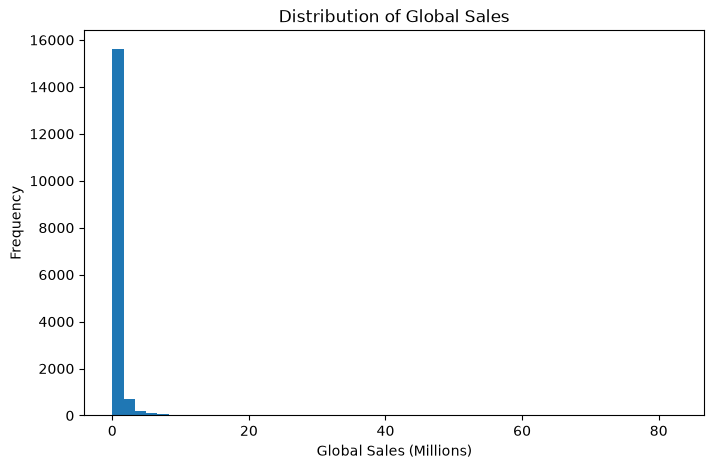

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Global_Sales"], bins=50)

plt.title("Distribution of Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Frequency")

plt.show()

In [17]:
df.columns

Index(['Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='str')

In [18]:
leakage_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales"
]

df = df.drop(columns=leakage_columns)

print("Leakage features removed.")

Leakage features removed.


In [20]:
if "Name" in df.columns:
    df = df.drop(columns=["Name"])

In [21]:
# Features and target

X = df.drop(columns=["Global_Sales"])
y = df["Global_Sales"]

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

Features Shape : (16719, 10)
Target Shape   : (16719,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 13375
Testing Samples  : 3344


In [23]:
# Identify column types
numerical_columns = X_train.select_dtypes(include=np.number).columns

categorical_columns = X_train.select_dtypes(include="object").columns

print("Numerical Features :", len(numerical_columns))
print("Categorical Features :", len(categorical_columns))

Numerical Features : 10
Categorical Features : 0


## Data Preprocessing

In [24]:
# Store training medians
train_medians = {}

for column in numerical_columns:
    median = X_train[column].median()

    train_medians[column] = median

    X_train[column] = X_train[column].fillna(median)
    X_test[column] = X_test[column].fillna(median)

In [25]:
train_modes = {}

for column in categorical_columns:

    mode = X_train[column].mode()[0]

    train_modes[column] = mode

    X_train[column] = X_train[column].fillna(mode)
    X_test[column] = X_test[column].fillna(mode)

In [26]:
print("Missing Values (Train):", X_train.isnull().sum().sum())
print("Missing Values (Test) :", X_test.isnull().sum().sum())

Missing Values (Train): 0
Missing Values (Test) : 0


In [27]:
label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    X_train[column] = encoder.fit_transform(X_train[column])

    X_test[column] = encoder.transform(X_test[column])

    label_encoders[column] = encoder

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
print("Training Mean :", X_train_scaled.mean())
print("Training Std  :", X_train_scaled.std())

Training Mean : -9.029869271837236e-16
Training Std  : 1.0


## Pytorch (deep learning)

In [30]:
X_train_scaled.shape

(13375, 10)

In [31]:
# numpy arrays to tensors
# Convert features

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

# Convert targets

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

In [32]:
print("Training Features :", X_train_tensor.shape)
print("Training Labels   :", y_train_tensor.shape)

print()

print("Testing Features :", X_test_tensor.shape)
print("Testing Labels   :", y_test_tensor.shape)

print()

print("Feature Data Type :", X_train_tensor.dtype)
print("Target Data Type  :", y_train_tensor.dtype)

Training Features : torch.Size([13375, 10])
Training Labels   : torch.Size([13375, 1])

Testing Features : torch.Size([3344, 10])
Testing Labels   : torch.Size([3344, 1])

Feature Data Type : torch.float32
Target Data Type  : torch.float32


In [33]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print(f"Training Samples : {len(train_dataset)}")
print(f"Testing Samples  : {len(test_dataset)}")

Training Samples : 13375
Testing Samples  : 3344


In [34]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [35]:
features, targets = next(iter(train_loader))

print("Feature Batch Shape :", features.shape)
print("Target Batch Shape  :", targets.shape)

Feature Batch Shape : torch.Size([32, 10])
Target Batch Shape  : torch.Size([32, 1])


In [36]:
batch_info = pd.DataFrame({
    "Metric": [
        "Training Samples",
        "Testing Samples",
        "Input Features",
        "Batch Size",
        "Training Batches",
        "Testing Batches"
    ],
    "Value": [
        len(train_dataset),
        len(test_dataset),
        X_train_tensor.shape[1],
        BATCH_SIZE,
        len(train_loader),
        len(test_loader)
    ]
})

fig = px.bar(
    batch_info,
    x="Metric",
    y="Value",
    title="Dataset and DataLoader Summary",
    text="Value"
)

fig.write_html("../outputs/figures/dataloader_summary.html")
fig.write_image("../outputs/figures/dataloader_summary.png")

fig.show()

## the neural network

In [37]:
class VideoGameSalesMLP(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)

        )

    def forward(self, x):

        return self.network(x)

In [38]:
INPUT_SIZE = X_train_tensor.shape[1]

model = VideoGameSalesMLP(INPUT_SIZE)

print(model)

VideoGameSalesMLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [39]:
# Define the device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move the model to the device
model = model.to(DEVICE)

# Print the device
print(f"Model Device: {next(model.parameters()).device}")

Model Device: cpu


In [40]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 2,817
Trainable Parameters : 2,817


In [41]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.13.0+cpu
None
False


In [42]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA Available: False
GPU Count: 0


In [43]:
architecture = pd.DataFrame({
    "Layer": [
        "Input",
        "Hidden Layer 1",
        "Hidden Layer 2",
        "Output"
    ],
    "Neurons": [
        10,
        64,
        32,
        1
    ]
})

fig = px.bar(
    architecture,
    x="Layer",
    y="Neurons",
    text="Neurons",
    title="Neural Network Architecture"
)

fig.write_image("../outputs/figures/network_architecture.png")

fig.show()

In [44]:
params = pd.DataFrame({
    "Layer": [
        "Input → Hidden1",
        "Hidden1 → Hidden2",
        "Hidden2 → Output"
    ],
    "Parameters": [
        704,
        2080,
        33
    ]
})

fig = px.pie(
    params,
    names="Layer",
    values="Parameters",
    title="Parameter Distribution"
)

fig.write_image("../outputs/figures/parameter_distribution.png")

fig.show()

# learning

In [45]:
criterion = nn.MSELoss()

print(criterion)

MSELoss()


In [46]:
LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [47]:
EPOCHS = 100
hyperparameters = pd.DataFrame({
    "Hyperparameter": [
        "Input Features",
        "Hidden Layer 1",
        "Hidden Layer 2",
        "Output Layer",
        "Batch Size",
        "Learning Rate",
        "Epochs",
        "Optimizer",
        "Loss Function"
    ],
    "Value": [
        INPUT_SIZE,
        64,
        32,
        1,
        BATCH_SIZE,
        LEARNING_RATE,
        EPOCHS,
        "Adam",
        "MSELoss"
    ]
})

hyperparameters.to_csv(
    "../outputs/metrics/hyperparameters.csv",
    index=False
)

display(hyperparameters)

,Hyperparameter,Value
0,Input Features,10
1,Hidden Layer 1,64
2,Hidden Layer 2,32
3,Output Layer,1
4,Batch Size,32
5,Learning Rate,0.001
6,Epochs,100
7,Optimizer,Adam
8,Loss Function,MSELoss


In [48]:
fig = px.bar(
    hyperparameters,
    x="Hyperparameter",
    y="Value",
    title="Training Configuration",
    text="Value"
)

fig.write_image("../outputs/figures/training_configuration.png")

fig.show()

## training the neural net

In [49]:
train_losses = []
validation_losses = []

best_loss = float("inf")

In [50]:
for epoch in range(EPOCHS):

    # Training Mode
    model.train()

    running_train_loss = 0.0

    for features, targets in train_loader:

        features = features.to(DEVICE)
        targets = targets.to(DEVICE)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(features)

        # Compute loss
        loss = criterion(predictions, targets)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()

    running_validation_loss = 0.0

    with torch.no_grad():

        for features, targets in test_loader:

            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            predictions = model(features)

            loss = criterion(predictions, targets)

            running_validation_loss += loss.item()

    epoch_validation_loss = running_validation_loss / len(test_loader)

    validation_losses.append(epoch_validation_loss)

    # Save Best Model
    if epoch_validation_loss < best_loss:

        best_loss = epoch_validation_loss

        torch.save(
            model.state_dict(),
            "../models/video_game_sales_mlp.pth"
        )

    # Progress
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Validation Loss: {epoch_validation_loss:.4f}"
    )

Epoch [1/100] | Train Loss: 1.7001 | Validation Loss: 3.7464
Epoch [2/100] | Train Loss: 1.5910 | Validation Loss: 3.6788
Epoch [3/100] | Train Loss: 1.5418 | Validation Loss: 3.6941
Epoch [4/100] | Train Loss: 1.5123 | Validation Loss: 3.6387
Epoch [5/100] | Train Loss: 1.4747 | Validation Loss: 3.6296
Epoch [6/100] | Train Loss: 1.4555 | Validation Loss: 3.5988
Epoch [7/100] | Train Loss: 1.4337 | Validation Loss: 3.5827
Epoch [8/100] | Train Loss: 1.4118 | Validation Loss: 3.5609
Epoch [9/100] | Train Loss: 1.4016 | Validation Loss: 3.5464
Epoch [10/100] | Train Loss: 1.3762 | Validation Loss: 3.5101
Epoch [11/100] | Train Loss: 1.3683 | Validation Loss: 3.4877
Epoch [12/100] | Train Loss: 1.3619 | Validation Loss: 3.5393
Epoch [13/100] | Train Loss: 1.3570 | Validation Loss: 3.4579
Epoch [14/100] | Train Loss: 1.3343 | Validation Loss: 3.4867
Epoch [15/100] | Train Loss: 1.3362 | Validation Loss: 3.4571
Epoch [16/100] | Train Loss: 1.3193 | Validation Loss: 3.4389
Epoch [17/100] | 

In [51]:
history = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Training Loss": train_losses,
    "Validation Loss": validation_losses
})

history.to_csv(
    "../outputs/metrics/training_history.csv",
    index=False
)

history.head()

,Epoch,Training Loss,Validation Loss
0,1,1.700054,3.746398
1,2,1.591021,3.678765
2,3,1.541787,3.694084
3,4,1.512285,3.638749
4,5,1.474682,3.629596


In [52]:
history_long = history.melt(
    id_vars="Epoch",
    var_name="Dataset",
    value_name="Loss"
)

fig = px.line(
    history_long,
    x="Epoch",
    y="Loss",
    color="Dataset",
    markers=True,
    title="Training and Validation Loss"
)

fig.write_image("../outputs/figures/loss_curve.png")

fig.show()

In [53]:
best_epoch = history["Validation Loss"].idxmin()

best_results = pd.DataFrame({
    "Metric": [
        "Best Epoch",
        "Best Validation Loss",
        "Final Training Loss",
        "Final Validation Loss"
    ],
    "Value": [
        best_epoch + 1,
        history["Validation Loss"].min(),
        history["Training Loss"].iloc[-1],
        history["Validation Loss"].iloc[-1]
    ]
})

best_results.to_csv(
    "../outputs/metrics/best_results.csv",
    index=False
)

best_results

,Metric,Value
0,Best Epoch,94.000000
1,Best Validation Loss,2.740342
2,Final Training Loss,0.844026
3,Final Validation Loss,3.038806


In [54]:
summary = pd.DataFrame({
    "Metric": [
        "Initial Training Loss",
        "Final Training Loss",
        "Initial Validation Loss",
        "Final Validation Loss"
    ],
    "Loss": [
        history["Training Loss"].iloc[0],
        history["Training Loss"].iloc[-1],
        history["Validation Loss"].iloc[0],
        history["Validation Loss"].iloc[-1]
    ]
})

fig = px.bar(
    summary,
    x="Metric",
    y="Loss",
    text="Loss",
    title="Training Progress Summary"
)

fig.write_html("../outputs/figures/training_summary.html")
fig.write_image("../outputs/figures/training_summary.png")

fig.show()

## Model evaluation

In [55]:
# Load the best model

model.load_state_dict(
    torch.load("../models/video_game_sales_mlp.pth", map_location=DEVICE)
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [56]:
# Generate predictions

predictions = []

actual_values = []

with torch.no_grad():

    for features, targets in test_loader:

        features = features.to(DEVICE)

        outputs = model(features)

        predictions.extend(outputs.cpu().numpy().flatten())

        actual_values.extend(targets.numpy().flatten())

In [57]:
predictions = np.array(predictions)

actual_values = np.array(actual_values)

In [58]:
mae = mean_absolute_error(actual_values, predictions)

mse = mean_squared_error(actual_values, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(actual_values, predictions)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.4998
MSE  : 2.7527
RMSE : 1.6591
R²   : 0.3332


In [59]:
metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

metrics.to_csv(
    "../outputs/metrics/evaluation_metrics.csv",
    index=False
)

metrics

,Metric,Value
0,MAE,0.499765
1,MSE,2.752667
2,RMSE,1.659116
3,R²,0.333164


In [60]:
results = pd.DataFrame({
    "Actual": actual_values,
    "Predicted": predictions
})

fig = px.scatter(
    results,
    x="Actual",
    y="Predicted",
    opacity=0.6,
    title="Actual vs Predicted Global Sales"
)

# Perfect prediction line
max_value = max(results["Actual"].max(), results["Predicted"].max())

fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=max_value,
    y1=max_value,
    line=dict(color="red", dash="dash")
)

fig.write_image("../outputs/figures/actual_vs_predicted.png")

fig.show()

In [61]:
results["Residual"] = (
    results["Actual"] - results["Predicted"]
)

fig = px.histogram(
    results,
    x="Residual",
    nbins=50,
    title="Residual Distribution"
)

fig.write_image("../outputs/figures/residual_distribution.png")

fig.show()

In [62]:
fig = px.scatter(
    results,
    x="Predicted",
    y="Residual",
    opacity=0.6,
    title="Residuals vs Predicted Values"
)

fig.add_hline(y=0)

fig.write_image("../outputs/figures/residuals_vs_predictions.png")

fig.show()

In [63]:
results.to_csv(
    "../outputs/predictions/predictions.csv",
    index=False
)

results.head()

,Actual,Predicted,Residual
0,0.23,0.615224,-0.385224
1,0.01,0.266687,-0.256687
2,0.12,0.103745,0.016255
3,0.09,0.423492,-0.333492
4,0.16,0.247176,-0.087176


In [64]:
summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

fig = px.bar(
    summary,
    x="Metric",
    y="Value",
    text="Value",
    title="Regression Performance Metrics"
)

fig.write_image("../outputs/figures/regression_metrics.png")

fig.show()

In [65]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Neural Network (MLP)"
    ],
    "MAE": [
        0.534245,
        0.383721,
        mae
    ],
    "RMSE": [
        1.823624,
        1.634367,
        rmse
    ],
    "R²": [
        0.194370,
        0.352910,
        r2
    ]
})

In [66]:
fig = px.bar(
    comparison,
    x="Model",
    y="MAE",
    text="MAE",
    title="Model Comparison - Mean Absolute Error"
)

fig.write_image("../outputs/figures/model_comparison_mae.png")

fig.show()

In [67]:
fig = px.bar(
    comparison,
    x="Model",
    y="RMSE",
    text="RMSE",
    title="Model Comparison - Root Mean Squared Error"
)

fig.write_image("../outputs/figures/model_comparison_rmse.png")

fig.show()

In [68]:
fig = px.bar(
    comparison,
    x="Model",
    y="R²",
    text="R²",
    title="Model Comparison - R² Score"
)

fig.write_image("../outputs/figures/model_comparison_r2.png")

fig.show()